In [ ]:
# Import-Block
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Zusatz zum Import
plt.style.use("ggplot")
pd.set_option("display.float_format", "{:.2f}".format)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

In [ ]:
# Daten-Datei
data = pd.read_csv("01_fitness_tracker.csv")

data.head()
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       500 non-null    object 
 1   Workout Duration (mins)  500 non-null    int64  
 2   Calories Burned          500 non-null    float64
 3   Step Count               500 non-null    int64  
 4   Heart Rate               500 non-null    int64  
dtypes: float64(1), int64(3), object(1)
memory usage: 19.7+ KB


,Workout Duration (mins),Calories Burned,Step Count,Heart Rate
count,500.00,500.00,500.00,500.00
mean,67.86,543.62,10640.51,117.10
std,30.01,266.13,5487.76,34.39
min,15.00,54.18,1035.00,60.00
25%,42.00,327.25,6088.00,89.00
50%,69.00,555.84,11074.00,116.50
75%,94.00,775.98,15432.75,145.00
max,119.00,999.01,19982.00,179.00


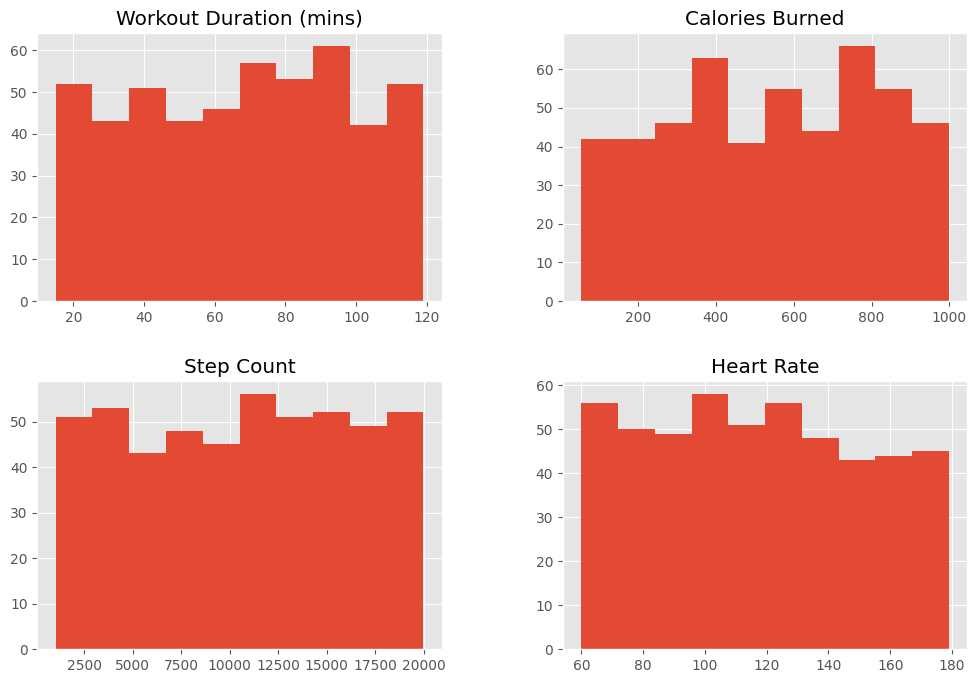

In [4]:
# Erste Insight (EDA)
data.hist(figsize=(12,8))
plt.show()

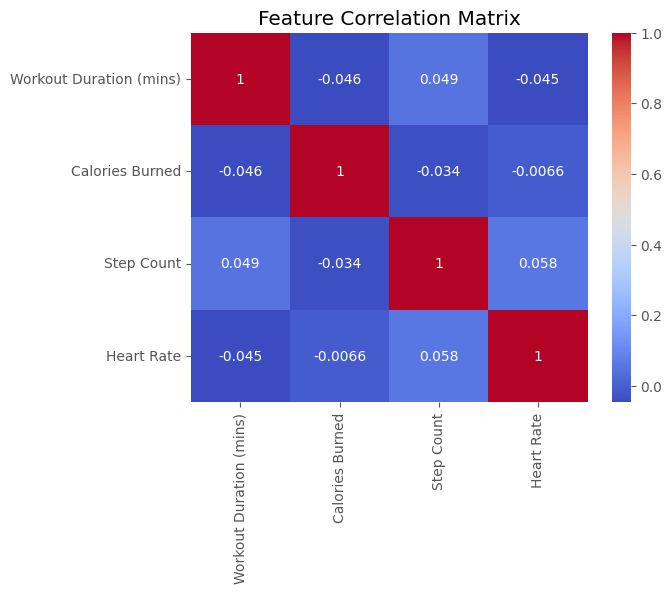

In [5]:
# Korrelationen
corr = data.drop(columns=["ID"]).corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

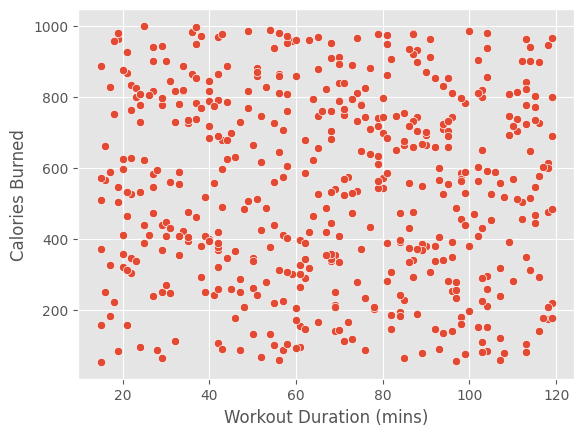

In [6]:
# Calories vs Duration
sns.scatterplot(x="Workout Duration (mins)", y="Calories Burned", data=data)
plt.show()

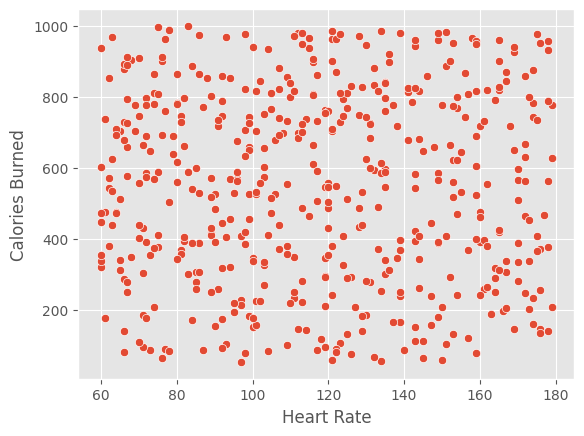

In [7]:
# Calories vs Heart Rate
sns.scatterplot(x="Heart Rate", y="Calories Burned", data=data)
plt.show()

In [8]:
# Calories per minute
data["Calories_per_min"] = data["Calories Burned"] / data["Workout Duration (mins)"]
data.head()

,ID,Workout Duration (mins),Calories Burned,Step Count,Heart Rate,Calories_per_min
0,FT0001,69,356.18,11146,73,5.16
1,FT0002,79,717.97,16173,138,9.09
2,FT0003,85,229.37,1232,97,2.70
3,FT0004,118,944.68,13318,130,8.01
4,FT0005,56,811.48,15984,74,14.49


In [9]:
# Feature Engineering
data["Steps_per_min"] = data["Step Count"] / data["Workout Duration (mins)"]
data["HR_per_min"] = data["Heart Rate"] / data["Workout Duration (mins)"]

In [10]:
# ML-Modell (Vorhersage)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = data[["Workout Duration (mins)", "Step Count", "Heart Rate"]]
y = data["Calories Burned"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

print("R² Score:", model.score(X_test, y_test))


R² Score: -0.028756750717824353


In [11]:
# ML-Vorbereitung
from sklearn.model_selection import train_test_split

X = data[["Workout Duration (mins)", "Step Count", "Heart Rate"]]
y = data["Calories Burned"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
# Linear Regression (Baseline)
from sklearn.linear_model import LinearRegression

lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

print("Linear Regression R²:", lin_model.score(X_test, y_test))

Linear Regression R²: -0.028756750717824353


In [13]:
# Random Forest
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest R²:", rf_model.score(X_test, y_test))

Random Forest R²: -0.10082542417187845


In [14]:
# Gradient Boosting
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(random_state=42)
gb_model.fit(X_train, y_train)

print("Gradient Boosting R²:", gb_model.score(X_test, y_test))

Gradient Boosting R²: -0.04115761709822441


In [15]:
# Modelle vergleichen
models = {
    "Linear Regression": lin_model.score(X_test, y_test),
    "Random Forest": rf_model.score(X_test, y_test),
    "Gradient Boosting": gb_model.score(X_test, y_test)
}

models

{'Linear Regression': -0.028756750717824353,
 'Random Forest': -0.10082542417187845,
 'Gradient Boosting': -0.04115761709822441}

<Axes: >

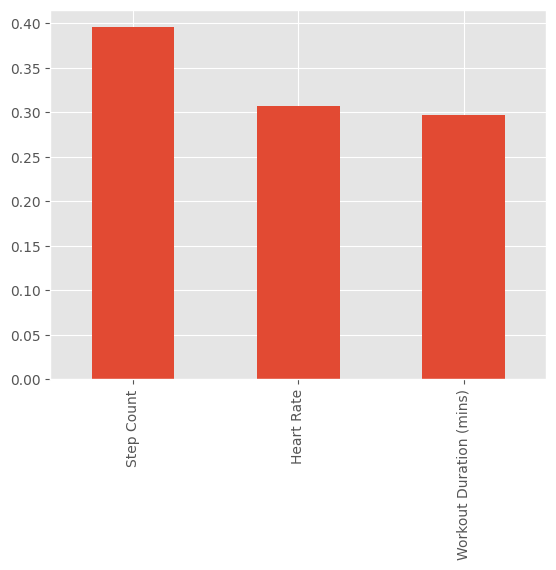

In [16]:
# Feature Importance
import pandas as pd

importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importance.plot(kind="bar")

In [17]:
# Model Comparison Block
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [18]:
# Train / Test Split
X = data[["Workout Duration (mins)", "Step Count", "Heart Rate"]]
y = data["Calories Burned"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
# Modell-Definition
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

In [20]:
# Vergleich
results = []

for name, model in models.items():
    
    # Trainieren
    model.fit(X_train, y_train)
    
    # Vorhersage
    y_pred = model.predict(X_test)
    
    # Test Performance
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    # Cross Validation
    cv_r2 = cross_val_score(model, X, y, cv=5, scoring="r2").mean()
    
    cv_scores = cross_val_score(model, X, y, cv=5, scoring="r2")
    
    results.append({
    "Model": name,
    "Test R2": round(r2, 4),
    "CV R2 (mean)": round(cv_scores.mean(), 4),
    "CV R2 (std)": round(cv_scores.std(), 4),
    "RMSE": round(rmse, 2)
    })

comparison_df = pd.DataFrame(results).sort_values(by="Test R2", ascending=False)

comparison_df

,Model,Test R2,CV R2 (mean),CV R2 (std),RMSE
0,Linear Regression,-0.03,-0.03,0.02,288.44
2,Gradient Boosting,-0.04,-0.14,0.06,290.18
1,Random Forest,-0.10,-0.20,0.09,298.38


In [21]:
# Overfitting-Indikator
overfit_gap = r2 - cv_scores.mean()

OverfitGap = round(overfit_gap, 4)
print(OverfitGap)

0.0942


In [22]:
# RMSE + R²
comparison_df["Score"] = (
    comparison_df["Test R2"] - 
    comparison_df["RMSE"] / comparison_df["RMSE"].max()
)

comparison_df.sort_values("Score", ascending=False)

,Model,Test R2,CV R2 (mean),CV R2 (std),RMSE,Score
0,Linear Regression,-0.03,-0.03,0.02,288.44,-1.00
2,Gradient Boosting,-0.04,-0.14,0.06,290.18,-1.01
1,Random Forest,-0.10,-0.20,0.09,298.38,-1.10


In [23]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X, y, cv=kf, scoring="r2")

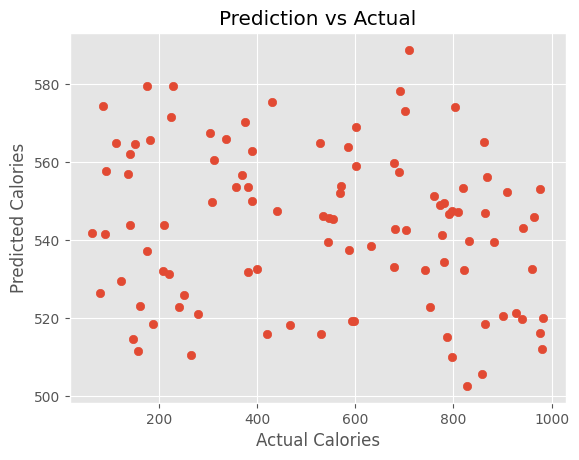

In [24]:
# Prediction vs Actual Plot
import matplotlib.pyplot as plt

best_model = models[comparison_df.iloc[0]["Model"]]
y_pred = best_model.predict(X_test)

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Calories")
plt.ylabel("Predicted Calories")
plt.title("Prediction vs Actual")
plt.show()

In [25]:
# Fazit:
# Underfitted, not enough data